In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_contacts)=
# Get contacts

*Computing contact maps and inter-atomic contact matrices.*

The function {func}`molsysmt.structure.get_contacts` calculates a boolean contact matrix or a list of interacting atom/centroid pairs where the Euclidean distance is below a specified cutoff threshold.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_contacts`.
:::


## Basic usage

Let's compute and plot the intra-chain C-alpha contact map of TcTIM (PDB ID: 1TCD):


In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['TcTIM']['1tcd.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We select all C-alpha atoms in the first chain and compute contacts using a threshold of `1.2 nm`:


In [4]:
ca_atoms_A = msm.select(molsys, selection='chain_id=="A" and atom_name=="CA"')
contact_map_A = msm.structure.get_contacts(molsys, selection=ca_atoms_A, threshold='1.2 nm')
print('Contact map shape:', contact_map_A.shape)
print(f'Total contacts: {np.sum(contact_map_A)}')


Contact map shape: (1, 248, 248)
Total contacts: 7764


We display the 2D boolean contact matrix using Matplotlib:


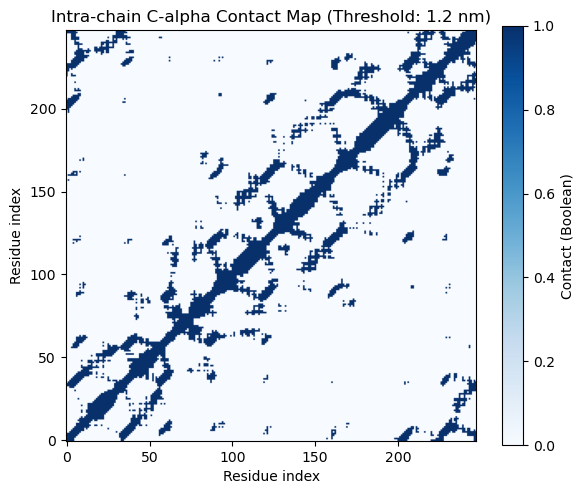

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(contact_map_A[0], cmap='Blues', origin='lower')
ax.set_title('Intra-chain C-alpha Contact Map (Threshold: 1.2 nm)')
ax.set_xlabel('Residue index')
ax.set_ylabel('Residue index')
plt.colorbar(im, ax=ax, label='Contact (Boolean)')
plt.tight_layout()
plt.show()


## Computing contacts between two different atom selections

By passing both `selection` and `selection_2`, we can evaluate cross-set contact maps (for instance, the binding interface between two distinct protein chains):


In [6]:
ca_atoms_B = msm.select(molsys, selection='chain_id=="B" and atom_name=="CA"')
inter_contacts = msm.structure.get_contacts(
    molsys,
    selection=ca_atoms_A,
    selection_2=ca_atoms_B,
    threshold='1.0 nm'
)
print('Inter-chain contact map shape:', inter_contacts.shape)
print(f'Inter-chain contacts (< 1.0 nm): {np.sum(inter_contacts)}')


Inter-chain contact map shape: (1, 248, 249)
Inter-chain contacts (< 1.0 nm): 279


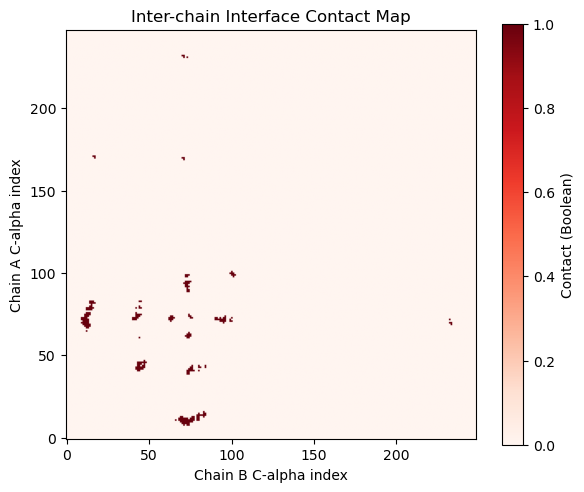

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(inter_contacts[0], cmap='Reds', origin='lower')
ax.set_title('Inter-chain Interface Contact Map')
ax.set_xlabel('Chain B C-alpha index')
ax.set_ylabel('Chain A C-alpha index')
plt.colorbar(im, ax=ax, label='Contact (Boolean)')
plt.tight_layout()
plt.show()


## Computing contacts between atom-group centroids

Using `center_of_atoms=True`, {func}`molsysmt.structure.get_contacts` calculates contacts between the geometric centroids of atom groups (such as entire amino acid residues) rather than single atoms:


In [8]:
groups_chainA = msm.get(molsys, element='group', selection='chain_id=="A"', atom_index=True)
centroid_contacts = msm.structure.get_contacts(
    molsys,
    selection=groups_chainA,
    center_of_atoms=True,
    threshold='0.8 nm'
)
print('Residue centroid contact map shape:', centroid_contacts.shape)
print(f'Residue centroid contacts (< 0.8 nm): {np.sum(centroid_contacts)}')


Residue centroid contact map shape: (1, 248, 248)
Residue centroid contacts (< 0.8 nm): 2776


## Querying contact pairs list

Setting `output_type='pairs'` and `output_indices='atom'` returns the contacting atom index pairs directly as a list instead of a full dense matrix:


In [9]:
contact_pairs = msm.structure.get_contacts(
    molsys,
    selection=ca_atoms_A,
    selection_2=ca_atoms_B,
    threshold='0.8 nm',
    output_type='pairs',
    output_indices='atom'
)
print(f'Total interacting atom pairs found: {len(contact_pairs[0])}')
print('First 5 interacting atom pairs (global atom indices):', contact_pairs[0][:5])


Total interacting atom pairs found: 103
First 5 interacting atom pairs (global atom indices): [[56, 2460], [78, 2440], [78, 2444], [78, 2449], [78, 2460]]


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Select <Tutorial_Select>`: Select atoms and elements with {func}`molsysmt.basic.select`.
- {ref}`Get <Tutorial_Get>`: Query elements, atom indices, and attributes with {func}`molsysmt.basic.get`.
- {ref}`Get distances <Tutorial_Get_distances>`: Calculate continuous inter-atomic distances with {func}`molsysmt.structure.get_distances`.
- {ref}`Get minimum distances <Tutorial_Get_minimum_distances>`: Measure closest-approach distances with {func}`molsysmt.structure.get_minimum_distances`.
- {ref}`Get neighbors <Tutorial_Get_neighbors>`: Query neighboring atoms and elements within distance cutoffs with {func}`molsysmt.structure.get_neighbors`.
:::
